<a href="https://colab.research.google.com/github/DivyaSS309/Advanced-Computing-and-ML-Project/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Q1. Sourcing the Dataset

In [ ]:
# Loading the dataset (on Google Colab)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [ ]:
dftest = pd.read_csv('/content/fraudTest.csv')

# Q2. Data Exploration and Visualtion

In [ ]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,42831.000000,4.283100e+04,42831.000000,42831.000000,42831.000000,42831.000000,4.283000e+04,4.283000e+04,42830.000000,42830.000000,42830.000000
mean,21415.000000,4.178002e+17,71.563338,48733.948939,38.536225,-90.241386,8.852743e+04,1.326469e+09,38.536078,-90.247263,0.009269
std,12364.389027,1.310122e+18,151.062206,27017.786941,5.091000,13.953112,2.977794e+05,6.255365e+05,5.121287,13.962830,0.095831
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.040141,-166.629875,0.000000
25%,10707.500000,1.800429e+14,9.690000,25832.000000,34.668900,-96.809400,7.430000e+02,1.325940e+09,34.785872,-96.940941,0.000000
50%,21415.000000,3.519607e+15,47.970000,48088.000000,39.346500,-87.456900,2.456000e+03,1.326489e+09,39.348741,-87.366152,0.000000
75%,32122.500000,4.642255e+15,83.680000,72042.000000,41.846700,-80.128400,2.047800e+04,1.327043e+09,41.924197,-80.174018,0.000000
max,42830.000000,4.992346e+18,11872.210000,99783.000000,65.689900,-12.000000,2.906700e+06,1.327591e+09,66.659242,-66.967742,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42831 entries, 0 to 42830
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             42831 non-null  int64  
 1   trans_date_trans_time  42831 non-null  object 
 2   cc_num                 42831 non-null  int64  
 3   merchant               42831 non-null  object 
 4   category               42831 non-null  object 
 5   amt                    42831 non-null  float64
 6   first                  42831 non-null  object 
 7   last                   42831 non-null  object 
 8   gender                 42831 non-null  object 
 9   street                 42831 non-null  object 
 10  city                   42831 non-null  object 
 11  state                  42831 non-null  object 
 12  zip                    42831 non-null  int64  
 13  lat                    42831 non-null  float64
 14  long                   42831 non-null  float64
 15  ci

The data shows no missing values

In [ ]:
# Check how amount is distributed

df['amt'].describe()

,amt
count,42831.000000
mean,71.563338
std,151.062206
min,1.000000
25%,9.690000
50%,47.970000
75%,83.680000
max,11872.210000


In [ ]:
# Total # of fraudulent transactions

df.is_fraud.value_counts()

,count
is_fraud,
0.0,42433
1.0,397


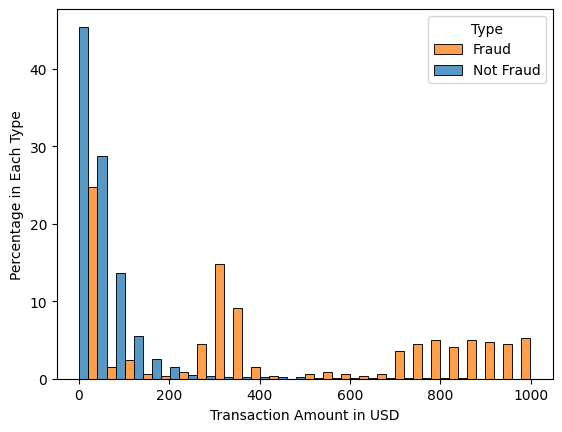

In [ ]:


# Amount vs fraud

df['amt'] = pd.to_numeric(df['amt'], errors='coerce')
df_plot = df.dropna(subset=['amt'])

ax=sns.histplot(x='amt',data=df_plot[df_plot.amt<=1000],hue='is_fraud',stat='percent',multiple='dodge',common_norm=False,bins=25)
ax.set_ylabel('Percentage in Each Type')
ax.set_xlabel('Transaction Amount in USD')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The result is very interesting!
* Normal transactions tend to be around USD 200 or less
* Fraudulent transactions peak around USD 300 and then at the USD 800-1000 range. There are also a lot of small dollar value fradulent transactions

In [ ]:
# Spending category vs fraud

#calculate the percentage difference
a=df[df['is_fraud']==0]['category'].value_counts(normalize=True).to_frame().reset_index()
a.columns=['category','not fraud percentage']

b=df[df['is_fraud']==1]['category'].value_counts(normalize=True).to_frame().reset_index()
b.columns=['category','fraud percentage']
ab=a.merge(b,on='category')
ab['diff']=ab['fraud percentage']-ab['not fraud percentage']

ax=sns.barplot(y='category',x='diff',data=ab.sort_values('diff',ascending=False))
ax.set_xlabel('Percentage Difference')
ax.set_ylabel('Transaction Category')
plt.title('The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

Text(0.5, 1.0, 'The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

Some spending categories see more fraud than others! Fraud tends to happen more often in 'Shopping_net', 'Grocery_pos', and 'Misc_net'

In [ ]:
# Has age got anything to do with it?

import datetime as dt
df['age']=dt.date.today().year-pd.to_datetime(df['dob']).dt.year
dftest['age']=dt.date.today().year-pd.to_datetime(dftest['dob']).dt.year

ax=sns.kdeplot(x='age',data=df, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0,110,5))
plt.title('Age Distribution in Fraudulent vs Non-Fraudulent Transactions')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The age distribution is visibly different between 2 transaction types. In normal transactions, there are 2 peaks at the age of 37-38 and 49-50, while in fraudulent transactions, the age distribution is a little smoother and the second peak does include a wider age group from 50-65. This does suggest that older people are potentially more prone to fraud.

In [ ]:
# Time in the day vs Fraud

df['hour']=pd.to_datetime(df['trans_date_trans_time']).dt.hour
dftest['hour']=pd.to_datetime(dftest['trans_date_trans_time']).dt.hour

ax=sns.histplot(data=df, x="hour", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Time (Hour) in a Day')
plt.xticks(np.arange(0,24,1))
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent payments happen disproportionately around midnight when most people are asleep.

In [ ]:
# Day of week vs Fraud

df['day']=pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek
dftest['day']=pd.to_datetime(dftest['trans_date_trans_time']).dt.dayofweek

ax=sns.histplot(data=df, x="day", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_xticklabels(['',"Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_ylabel('Percentage')
ax.set_xlabel('Day of Week')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions tend to happen throughout the week

In [ ]:
# Month vs Fraud

df['month']=pd.to_datetime(df['trans_date_trans_time']).dt.month
dftest['month']=pd.to_datetime(dftest['trans_date_trans_time']).dt.month

ax=sns.histplot(data=df, x="month", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Month')
plt.xticks(np.arange(1,13,1))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul",'Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions are crowded between Jan and June

In [ ]:
# Correlation Matrix

%matplotlib inline
fig = plt.figure(figsize=(18,9))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
mask = np.triu(np.ones_like(numeric_df.corr()))
sns.heatmap(numeric_df.corr(), mask=mask, cmap='coolwarm', annot=True)

# Q3. Preprocessing

In [ ]:
# Remove all Personally Identifiable Information (PII)

df = df.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
dftest = dftest.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
df

All columns with raw PII data are dropped.

---



In [ ]:
df.duplicated().sum()

The dataset shows zero duplicate entries.

In [ ]:
# Dropping original columns

df = df.drop(columns= ['trans_date_trans_time'])

dftest = dftest.drop(columns= ['trans_date_trans_time'])

df

### Distance calculation
The dataset provides us with locations in terms of coordinates. In order to calculate the distance, we use the Haversine function to find the distance between the merchants and the location of the transactions





In [ ]:
# Distance calculation when given coordinates

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dist_lat = lat2 - lat1
    dist_lon = lon2 - lon1

    a = np.sin(dist_lat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dist_lon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [ ]:
df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

dftest['distance_km'] = haversine(dftest['lat'], dftest['long'], dftest['merch_lat'], dftest['merch_long'])

df['distance_km'].head()


In [ ]:
# Dropping original columns

df = df.drop(columns=['lat','long','merch_lat','merch_long'])

dftest = dftest.drop(columns=['lat','long','merch_lat','merch_long'])

df

## Feature Encoding and Scaling

### Target Encoding, One Hot Encoding and Scaling

Target encoding is applied to the "merchants" and the "jobs" columns. This allows to convert these columns into numerical values that the model can read. One hot encoding is applied to the "category","gender","day_of_week" to convert these columns into numerical data. Lastly we scale all the numerical data.

In [ ]:
# Applying target encoding on merchants

merchant_encoding = df.groupby('merchant')['is_fraud'].mean()
df['merchant_encoded'] = df['merchant'].map(merchant_encoding)

merchant_encoding = dftest.groupby('merchant')['is_fraud'].mean()
dftest['merchant_encoded'] = dftest['merchant'].map(merchant_encoding)

df

In [ ]:
# Applying target encoding on jobs

job_encoding = df.groupby('job')['is_fraud'].mean()
df['job_encoding'] = df['job'].map(job_encoding)

job_encoding = dftest.groupby('job')['is_fraud'].mean()
dftest['job_encoding'] = dftest['job'].map(job_encoding)

df

In [ ]:
# Dropping original columns

df = df.drop(columns =['merchant','job'])

dftest = dftest.drop(columns =['merchant','job'])

df

In [ ]:
# Splitting the dataset into numerical and catergorical columns

numerical_cols = ['amt', 'distance_km', 'city_pop', 'unix_time','hour']

categorical_cols = ['category','gender','day']

In [ ]:
# Isolate the columns to be standard scaled
scale_cols = [col for col in numerical_cols if col != 'amt']

# Apply the stateless log transformation to 'amt' on BOTH sets
df['amt_log'] = np.log1p(df['amt'])
dftest['amt_log'] = np.log1p(dftest['amt'])

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data (for the non-amt numerical columns)
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Transform the test data using the TRAIN parameters
dftest[scale_cols] = scaler.transform(dftest[scale_cols])

# Drop the original raw 'amt' column so your model only sees 'amt_log'
df = df.drop(columns=['amt'])
dftest = dftest.drop(columns=['amt'])

We scale down all other numerical columns such that mean is 0 and standard deviation is 1. For amt column, we use log transformation since there are a lot of small transactions (USD 5, 10, 15) and fewer large transaction (USD 100)

In [ ]:
# Applying one hot encoding to categorical columns

df = pd.get_dummies(df, columns = categorical_cols)

dftest = pd.get_dummies(dftest, columns = categorical_cols)

df

## Input-Target split

In [ ]:
# Split data into input and target

# Drop rows with NaN values in 'is_fraud' column
df.dropna(subset=['is_fraud'], inplace=True)
dftest.dropna(subset=['is_fraud'], inplace=True)

X_train_full = df.drop(columns=["is_fraud"], inplace=False)
Y_train_full = df["is_fraud"]

X_test = dftest.drop(columns=["is_fraud"], inplace=False)
Y_test = dftest["is_fraud"]

# Split the training data to create the Validation set (20%)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full,
    Y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=Y_train_full
)

In [ ]:
X_train

In [ ]:
X_test

In [ ]:
X_train_full

Training, Validation and Testing all preprocessed and have 32 features

# Q4. Supervised Learning


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, Y_train = smote.fit_resample(X_train, Y_train)

--- Random Forest Model for Fraud Detection ---
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best Hyperparameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Validation ROC-AUC Score: 0.9985

--- Validation Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13871
         1.0       0.75      0.91      0.82       136

    accuracy                           1.00     14007
   macro avg       0.87      0.95      0.91     14007
weighted avg       1.00      1.00      1.00     14007


--- Final Evaluation on Test Set ---
Test ROC-AUC Score: 0.9968

--- Test Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     54233
         1.0       0.88      0.69      0.77       215

    accuracy                           1.00     54448
   macro avg       0.94      0.85      0.89     544

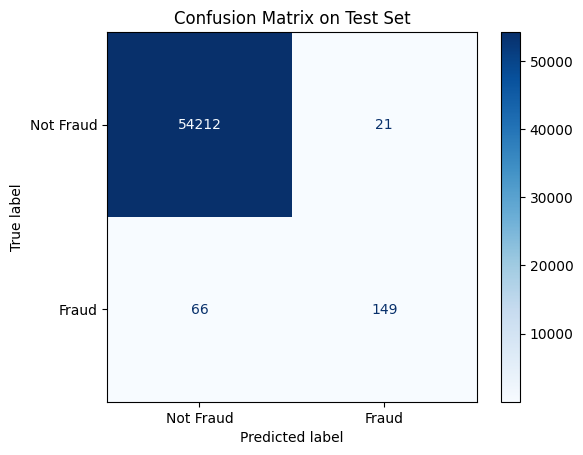

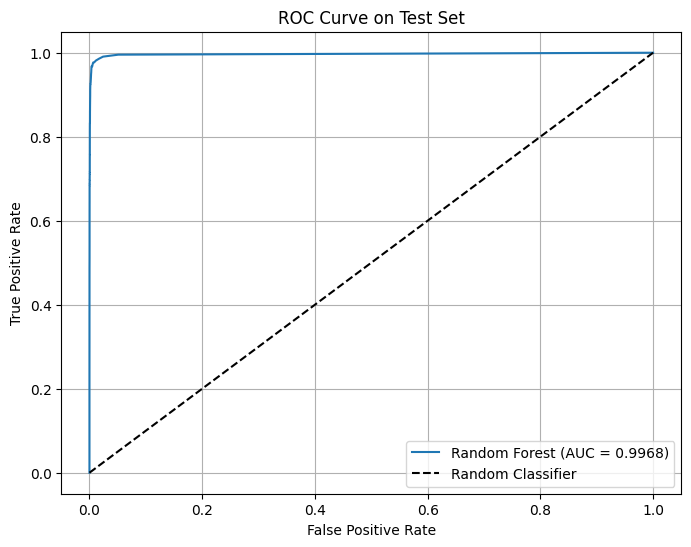

/tmp/ipykernel_2683/23083965.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


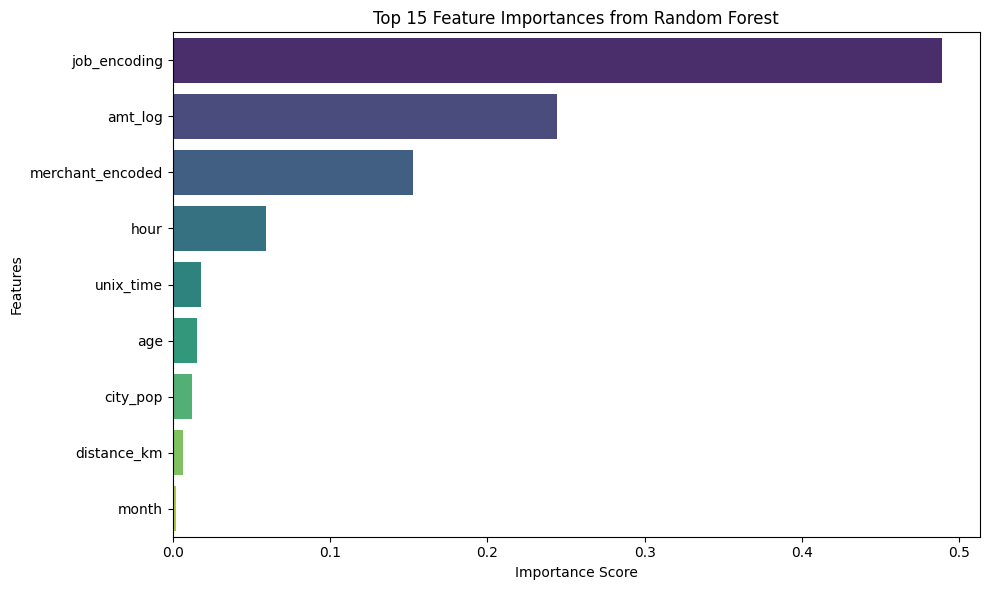

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np


print("--- Random Forest Model for Fraud Detection ---")

#Random Forest Classifier
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#Hyperparameter Grid for Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}



numerical_cols_for_model = X_train.select_dtypes(include=np.number).columns
X_train = X_train[numerical_cols_for_model]
X_val = X_val[numerical_cols_for_model]
X_test = X_test[numerical_cols_for_model]


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)


best_rf_model = grid_search.best_estimator_
print("\nBest Hyperparameters found:", grid_search.best_params_)


y_val_pred = best_rf_model.predict(X_val)
y_val_pred_proba = best_rf_model.predict_proba(X_val)[:, 1]  # Probabilities for the positive class

val_auc = roc_auc_score(Y_val, y_val_pred_proba)
print(f"\nValidation ROC-AUC Score: {val_auc:.4f}")
print("\n--- Validation Classification Report ---")
print(classification_report(Y_val, y_val_pred))

print("\n--- Final Evaluation on Test Set ---")
y_test_pred = best_rf_model.predict(X_test)
y_test_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(Y_test, y_test_pred_proba)
print(f"Test ROC-AUC Score: {test_auc:.4f}")
print("\n--- Test Classification Report ---")
print(classification_report(Y_test, y_test_pred))


#Confusion Matrix for Test Set
cm = confusion_matrix(Y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.show()

#ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, y_test_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


feature_importance = best_rf_model.feature_importances_
features = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


